<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_C8_Aprendizaje_Supervisado%2C_Regresion_(Libro).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En esta clase, aprenderemos a:

* Entender qué es el aprendizaje supervisado y sus diferencias con el no supervisado.
* Distinguir entre problemas de clasificación y regresión.
* Explorar la regresión logística para problemas de clasificación binaria.
*  Aplicar la regresión múltiple para predecir valores continuos.
*  Evaluar modelos de regresión y clasificación en Python.

Aplicaciones del Aprendizaje Supervisado

* Medicina: Diagnóstico de enfermedades basado en síntomas (Clasificación).
* Finanzas: Predicción del valor de una acción en la bolsa (Regresión).
* Marketing: Identificación de clientes que responderán a una campaña publicitaria (Clasificación).
* Industria Automotriz: Predicción del consumo de combustible de un automóvil (Regresión).


# Sección 1: Introducción al Aprendizaje Supervisado

Aprendizaje Supervisado vs. No Supervisado
Tipo de Aprendizaje | Descripción | Ejemplo
--------------------|-------------|--------------------------------------------------
Supervisado         | Se entrena con datos donde se conoce la respuesta correcta. | Clasificación de correos en spam o no spam.
No Supervisado      | El modelo encuentra patrones sin conocer etiquetas previas. | Agrupación de clientes según su comportamiento de compra.

Diferencia entre Clasificación y Regresión
Tipo de Problema | Descripción | Ejemplo
-----------------|-------------|-------------------------------------------
Clasificación    | Predice una categoría o clase. | Diagnóstico de enfermedades (Positivo/Negativo).
Regresión        | Predice un valor numérico continuo. | Predicción del precio de una casa.

**Diagrama de Decisión: ¿Clasificación o Regresión?**

* Si la variable a predecir es numérica continua → Usar Regresión.
* Si la variable a predecir es una categoría → Usar Clasificación.

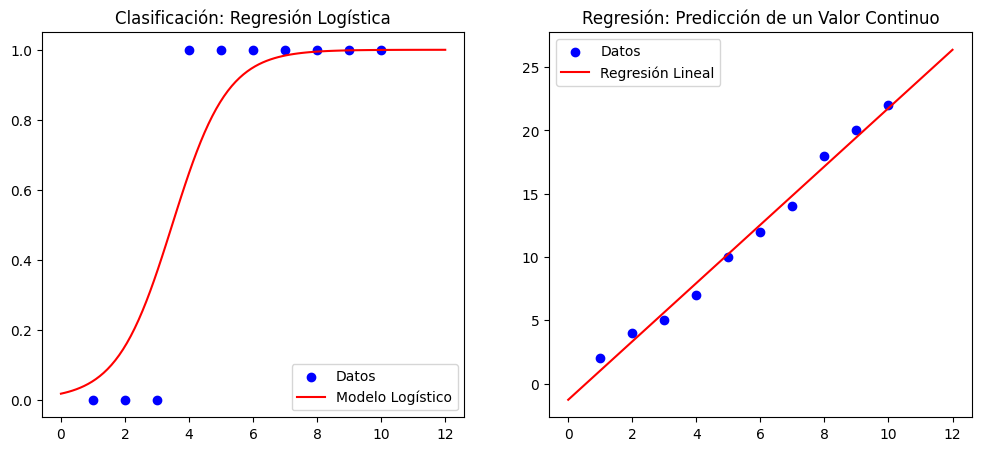

Conclusión:

    La Regresión Logística estima la probabilidad de una categoría (0 o 1).

    La Regresión Lineal estima un valor continuo.


In [ ]:
# 1.1. Implementación en Python – Clasificación vs. Regresión
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression

# Datos sintéticos
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y_class = np.array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1])
y_reg   = np.array([2, 4, 5, 7, 10, 12, 14, 18, 20, 22])

# Ajustar modelos
clf = LogisticRegression().fit(X, y_class)
reg = LinearRegression().fit(X, y_reg)

X_test = np.linspace(0, 12, 100).reshape(-1, 1)
y_pred_class = clf.predict_proba(X_test)[:, 1]
y_pred_reg   = reg.predict(X_test)

# Graficar
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X, y_class, color="blue", label="Datos")
plt.plot(X_test, y_pred_class, color="red", label="Modelo Logístico")
plt.title("Clasificación: Regresión Logística")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X, y_reg, color="blue", label="Datos")
plt.plot(X_test, y_pred_reg, color="red", label="Regresión Lineal")
plt.title("Regresión: Predicción de un Valor Continuo")
plt.legend()
plt.show()

print('Conclusión:\n')

print('    La Regresión Logística estima la probabilidad de una categoría (0 o 1).\n')
print('    La Regresión Lineal estima un valor continuo.')


# Sección 2: Regresión Logística
**2.2. Función Sigmoide**

La función sigmoide convierte cualquier valor en un rango de 0 a 1, facilitando la interpretación como probabilidad.

* Si el resultado es cercano a 1, el modelo predice clase 1 (ejemplo: "Aprobado").
* Si es cercano a 0, predice clase 0 (ejemplo: "Rechazado").

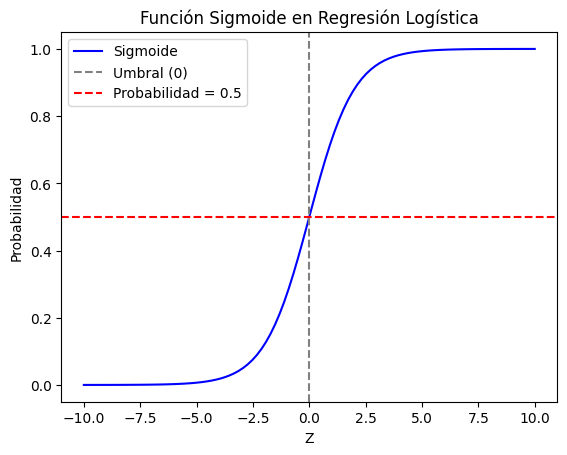

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
plt.plot(z, sigmoid(z), label="Sigmoide", color="blue")
plt.axvline(0, color="gray", linestyle="--", label="Umbral (0)")
plt.axhline(0.5, color="red", linestyle="--", label="Probabilidad = 0.5")
plt.xlabel("Z")
plt.ylabel("Probabilidad")
plt.title("Función Sigmoide en Regresión Logística")
plt.legend()
plt.show()

**2.3. Evaluación del Modelo**

Métricas para Regresión Logística
Métrica | Descripción
--------|-------------
Matriz de Confusión | Muestra verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.
Precisión | Proporción de predicciones correctas sobre el total.
Recall (Sensibilidad) | Capacidad del modelo para identificar correctamente la clase positiva.
Curva ROC-AUC | Evalúa el desempeño comparando Tasa de Verdaderos Positivos vs. Falsos Positivos.

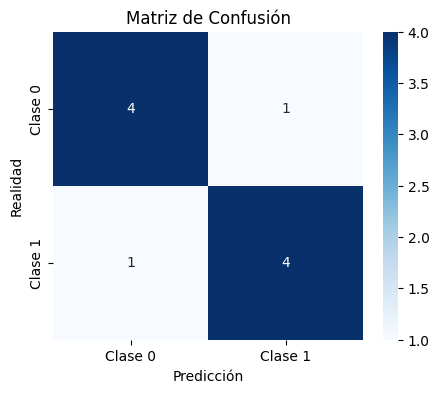

Reporte de Clasificación:               precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10

Conclusión:

    La matriz de confusión nos ayuda a ver los errores de clasificación.
    En salud, es mejor minimizar falsos negativos.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_real = [1, 0, 1, 1, 0, 1, 0, 0, 1, 0]
y_pred = [1, 0, 1, 0, 0, 1, 0, 1, 1, 0]

cm = confusion_matrix(y_real, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Clase 0","Clase 1"],
            yticklabels=["Clase 0","Clase 1"])
plt.xlabel("Predicción")
plt.ylabel("Realidad")
plt.title("Matriz de Confusión")
plt.show()

print("Reporte de Clasificación:", classification_report(y_real, y_pred))

print('Conclusión:\n')
print('    La matriz de confusión nos ayuda a ver los errores de clasificación.\n    En salud, es mejor minimizar falsos negativos.')

# Sección 3: Regresión Múltiple

**Objetivo**: Comprender el modelo de Regresión Múltiple, cómo interpretar sus coeficientes y aplicarlo en un caso práctico.

**3.1. ¿Qué es la Regresión Múltiple?**

La Regresión Múltiple es una extensión de la Regresión Lineal donde se utilizan múltiples variables predictoras para estimar un valor numérico:

Y = β₀ + β₁X₁ + β₂X₂ + ... + βₙXₙ + ε

    Y: variable dependiente (lo que queremos predecir).
    X₁, X₂, ..., Xₙ: variables independientes.
    β₀: intercepto.
    β₁, ..., βₙ: coeficientes de cada variable predictora.
    ε: error del modelo.


**3.2. Interpretación de los Coeficientes**
Variable | Coeficiente (β) | Interpretación
---------|-----------------|---------------------------------------------------------
Superficie (m²) | 500 | Por cada metro cuadrado adicional, el precio aumenta en $$500.
Número de habitaciones | 1500 | Por cada habitación adicional, el precio sube $1500.
Distancia al centro (km) | -2000 | Por cada kilómetro más lejos del centro, el precio baja $2000.

**3.3. Multicolinealidad en Regresión Múltiple**

Ocurre cuando dos o más variables independientes están fuertemente correlacionadas, afectando la estabilidad del modelo. Se detecta con la matriz de correlación o el Factor de Inflación de Varianza (VIF) — un VIF > 10 indica alta multicolinealidad.

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

data = {
    "Superficie":      [50, 60, 70, 80, 90, 100, 110, 120],
    "Habitaciones":    [2, 3, 3, 4, 4, 5, 5, 6],
    "Distancia_Centro":[5, 4, 3, 3, 2, 1, 1, 0]
}
df = pd.DataFrame(data)

vif_data = pd.DataFrame()
vif_data["Variable"] = df.columns
vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
print(vif_data)

           Variable         VIF
0        Superficie  313.910015
1      Habitaciones  297.961220
2  Distancia_Centro    2.227033


**3.4. Evaluación del Modelo**

Métricas para Regresión Múltiple

Métrica | Interpretación
--------|-----------------
R² (Coeficiente de Determinación) | Porcentaje de variabilidad explicada por el modelo (mayor es mejor, máximo 1).
MSE (Error Cuadrático Medio) | Error promedio cuadrático (menor es mejor).
MAE (Error Absoluto Medio) | Promedio de los errores absolutos (menor es mejor).

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_real = [200000, 220000, 250000, 270000, 300000]
y_pred = [210000, 225000, 240000, 260000, 295000]

print(f"R²:  {r2_score(y_real, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_real, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_real, y_pred):.2f}")

R²:  0.94
MSE: 70000000.00
MAE: 8000.00


# Sección 4: Ejercicio Integrador y Publicación en el Foro Obligatorio

Resolución en otro Notebook

# Regresión Múltiple en sklearn (Ejercicio del sincrónico)
**California Housing - predicción de precios**



In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np, statsmodels.api as sm

# 1. carga dataset
housing = fetch_california_housing()
df_h = pd.DataFrame(housing.data, columns=housing.feature_names)
df_h["Price"] = housing.target

# 2. Split
X = df_h.drop(columns=["Price"])
y = df_h["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Escalar (recomendado para comparar coeficientes)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# 4. Aplica Regresión Lineal para predecir el precio.
lr = LinearRegression().fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

# 5. Ridge (regularizado)
ridge = Ridge(alpha=1.0).fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)

# 6. Métricas
for nombre,y_pred in [("LR",y_pred_lr),("Ridge",y_pred_ridge)]:
  mae = mean_absolute_error(y_test, y_pred)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  r2 = r2_score(y_test, y_pred)
  print(f"{nombre}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}")

LR: MAE=0.53, RMSE=0.75, R2=0.58
Ridge: MAE=0.53, RMSE=0.75, R2=0.58


Valores similares porque  hay poca multicolinealidad.

R2 = 0.58 explica el 58% de varianza del precio

In [ ]:
# Ver coeficientes ordenados
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": lr.coef_
}).sort_values("Coeficiente", ascending=False)

print(coef_df.to_string(index=False))

  Variable  Coeficiente
    MedInc     0.854383
 AveBedrms     0.339259
  HouseAge     0.122546
Population    -0.002308
  AveOccup    -0.040829
  AveRooms    -0.294410
 Longitude    -0.869842
  Latitude    -0.896929
